In [68]:
import os
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal,Annotated
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage,HumanMessage,BaseMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from dotenv import load_dotenv

In [57]:
load_dotenv()

True

In [58]:
try:
    nvidia_api_key = os.getenv("NVIDIA_API_KEY")
    google_api_key=os.getenv("GEMINI_API_KEY2")
    gemini_api_key=os.getenv("api_key")
    groq_api_key=os.getenv("GROQ_API_KEY")
except Exception as e:
    print("Error is ",e)

In [59]:
llm=ChatGoogleGenerativeAI(
    model="gemini-3.8-flash", temperature=0.7,google_api_key=google_api_key
)
llm2=ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite", temperature=0.7,google_api_key=gemini_api_key
)
llm3=ChatGroq(model='openai/gpt-oss-20b',api_key=groq_api_key)

llm4= ChatOpenAI(
    base_url="https://integrate.api.nvidia.com/v1",
    api_key=nvidia_api_key,
    model="nvidia/nemotron-3.5-lightning-30b-a3b",
    temperature=0.2,
)

In [60]:
class ChatSatate(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]
    

In [61]:
def chat_node(state:ChatSatate):
    #take user query from state
    messages=state['messages']
    
    #send to llm
    
    response=llm3.invoke(messages)
    
    #response store state
    
    return {'messages':[response]}

In [62]:
checkpointer=MemorySaver()
graph=StateGraph(ChatSatate)

graph.add_node('chat_node',chat_node)

graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

chatbot=graph.compile(checkpointer=checkpointer)


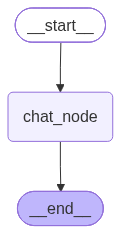

In [63]:
chatbot

In [64]:
thread_id='1'
while True:
    user_query=input('Enter your Messages:')
    print("User: ",user_query)
    if user_query.strip().lower() in['exit','quit','bye','end']:
        break
    
    config={'configurable':{'thread_id':thread_id}}
    response=chatbot.invoke({'messages':[HumanMessage(content=user_query)]},config=config)
    
    #   print('AI: ',response['messages'][-1].content[0]['text'])
    print('AI: ',response['messages'][-1].content)

User:  hi my name is samrat
AI:  Hello Samrat! 👋 How can I help you today?
User:  whats my name
AI:  Your name is Samrat.
User:  gg dude
AI:  Thanks, Samrat! If you need anything else, just let me know. Take care!
User:  what is 3+5
AI:  3 + 5 = 8.
User:  and result +10
AI:  8 + 10 = 18.
User:  gg dude
AI:  Thanks, Samrat! 🎮 Have a great day!
User:  end


In [67]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi my name is samrat', additional_kwargs={}, response_metadata={}, id='08dcc5ed-848b-4ff0-9eac-107775662911'), AIMessage(content='Hello Samrat! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "hi my name is samrat". We need to respond accordingly, friendly. No policy issues. Just greet them.'}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 77, 'total_tokens': 127, 'completion_time': 0.056101586, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.004331128, 'prompt_tokens_details': None, 'queue_time': 0.347258018, 'total_time': 0.060432714}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_228717f27c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0e6d9-59f9-7662-8100-011caa9bfb20-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'outpu